In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/dataset_info.txt
/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/README.md
/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/feature_description.csv
/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/final_dataset.csv


In [2]:
import os

# TensorFlow loglarını azaltır.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import gc
import json
import pickle
import random
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

2026-06-13 09:41:58.972530: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781343719.212281      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781343719.279018      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781343719.813694      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781343719.813737      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781343719.813740      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
CSV_PATH = (
    "/kaggle/input/datasets/elifzelik/"
    "phishing-url-features-dataset/final_dataset.csv"
)

df = pd.read_csv(
    CSV_PATH,
    usecols=["url", "label"]
)

df = df.dropna(subset=["url", "label"]).copy()
df["url"] = df["url"].astype(str)
df["label"] = df["label"].astype(np.int8)

print("Dataset shape:", df.shape)
display(df.head())

print("\nLabel counts:")
print(df["label"].value_counts())

print("\nLabel ratios:")
print(df["label"].value_counts(normalize=True))

Dataset shape: (579920, 2)


,url,label
0,http://%20%25**)(**@fbrasil.com/old/lqjj0ukuvg...,1
1,https://*f003.backblazeb2.com*/file/pesosi/hom...,1
2,http://0-docusign-secured-843439-1-srs09.repli...,1
3,http://0-olx.1850943.xyz/,1
4,http://0.0.0.0forum.cryptonight.net,1



Label counts:
label
0    339074
1    240846
Name: count, dtype: int64

Label ratios:
label
0    0.584691
1    0.415309
Name: proportion, dtype: float64


In [4]:
print("Duplicate URL rows:", df["url"].duplicated().sum())

label_counts_per_url = df.groupby("url")["label"].nunique()
conflicting_url_count = (label_counts_per_url > 1).sum()

print("URLs with conflicting labels:", conflicting_url_count)

Duplicate URL rows: 0
URLs with conflicting labels: 0


In [5]:
conflicting_urls = label_counts_per_url[
    label_counts_per_url > 1
].index

if len(conflicting_urls) > 0:
    display(
        df[df["url"].isin(conflicting_urls)]
        .sort_values("url")
        .head(20)
    )

In [6]:
urls = df["url"].to_numpy()
labels = df["label"].to_numpy()

X_train_url, X_temp_url, y_train, y_temp = train_test_split(
    urls,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

X_val_url, X_test_url, y_val, y_test = train_test_split(
    X_temp_url,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train samples:", len(X_train_url))
print("Validation samples:", len(X_val_url))
print("Test samples:", len(X_test_url))

print("\nTrain label ratios:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nValidation label ratios:")
print(pd.Series(y_val).value_counts(normalize=True))

print("\nTest label ratios:")
print(pd.Series(y_test).value_counts(normalize=True))

Train samples: 405944
Validation samples: 86988
Test samples: 86988

Train label ratios:
0    0.584691
1    0.415309
Name: proportion, dtype: float64

Validation label ratios:
0    0.58469
1    0.41531
Name: proportion, dtype: float64

Test label ratios:
0    0.58469
1    0.41531
Name: proportion, dtype: float64


{'mean': 51.65795282107877, 'median': 41.0, 'p90': 82.0, 'p95': 110.0, 'p99': 212.0, 'max': 25523}


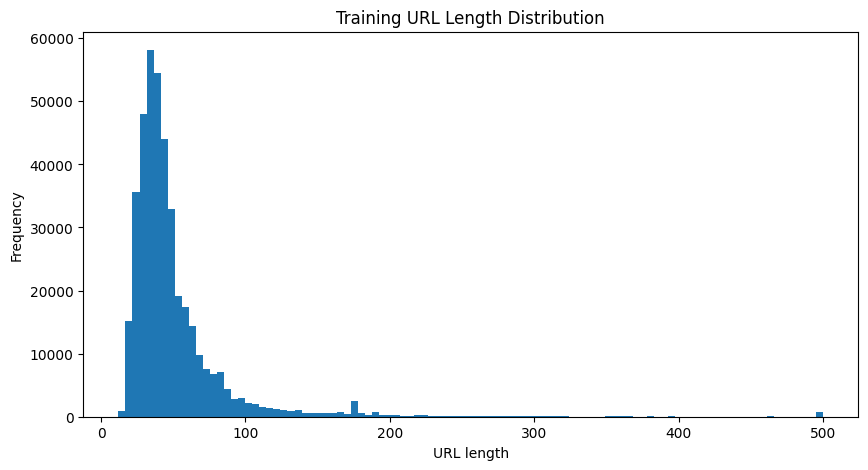

In [7]:
train_url_lengths = pd.Series(X_train_url).str.len()

length_stats = {
    "mean": float(train_url_lengths.mean()),
    "median": float(train_url_lengths.median()),
    "p90": float(np.percentile(train_url_lengths, 90)),
    "p95": float(np.percentile(train_url_lengths, 95)),
    "p99": float(np.percentile(train_url_lengths, 99)),
    "max": int(train_url_lengths.max())
}

print(length_stats)

plt.figure(figsize=(10, 5))
plt.hist(
    train_url_lengths.clip(upper=500),
    bins=100
)
plt.title("Training URL Length Distribution")
plt.xlabel("URL length")
plt.ylabel("Frequency")
plt.show()

In [8]:
MAX_LEN = 250
MAX_CHARS = 150

tokenizer = Tokenizer(
    num_words=MAX_CHARS,
    char_level=True,
    lower=False,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_url)

vocab_size = min(
    MAX_CHARS,
    len(tokenizer.word_index) + 1
)

print("Vocabulary size:", vocab_size)
print("Character count:", len(tokenizer.word_index))
print("First tokenizer entries:")
print(list(tokenizer.word_index.items())[:20])

Vocabulary size: 150
Character count: 880
First tokenizer entries:
[('<OOV>', 1), ('t', 2), ('/', 3), ('e', 4), ('s', 5), ('o', 6), ('a', 7), ('p', 8), ('.', 9), ('i', 10), ('c', 11), ('r', 12), ('n', 13), ('h', 14), ('w', 15), ('m', 16), ('l', 17), ('d', 18), ('-', 19), ('u', 20)]


In [9]:
X_train_seq = tokenizer.texts_to_sequences(X_train_url)
X_val_seq = tokenizer.texts_to_sequences(X_val_url)
X_test_seq = tokenizer.texts_to_sequences(X_test_url)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    dtype="int32"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    dtype="int32"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    dtype="int32"
)

print("Train:", X_train_pad.shape, X_train_pad.dtype)
print("Validation:", X_val_pad.shape, X_val_pad.dtype)
print("Test:", X_test_pad.shape, X_test_pad.dtype)

# Büyük Python listelerini temizleyerek RAM aç.
del X_train_seq, X_val_seq, X_test_seq
gc.collect()

Train: (405944, 250) int32
Validation: (86988, 250) int32
Test: (86988, 250) int32


0

In [10]:
classes = np.unique(y_train)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {
    int(label): float(weight)
    for label, weight in zip(classes, class_weight_values)
}

print("Class weights:", class_weight)

Class weights: {0: 0.8551518419899559, 1: 1.203924266869128}


In [11]:
SAVE_DIR = "/kaggle/working/model_2_bilstm"

os.makedirs(SAVE_DIR, exist_ok=True)

print("Save directory:", SAVE_DIR)

Save directory: /kaggle/working/model_2_bilstm


In [12]:
def build_callbacks(model_name):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f"{SAVE_DIR}/{model_name}.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

In [13]:
def find_best_threshold(
    y_true,
    y_prob,
    start=0.05,
    stop=0.95,
    step=0.005
):
    thresholds = np.arange(start, stop + step, step)

    best_threshold = 0.5
    best_f1 = -1.0

    records = []

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(np.int8)

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )
        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )
        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        records.append({
            "threshold": float(threshold),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1)
        })

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    threshold_df = pd.DataFrame(records)

    return float(best_threshold), float(best_f1), threshold_df

In [14]:
def evaluate_probabilities(
    y_true,
    y_prob,
    model_name,
    threshold
):
    y_pred = (y_prob >= threshold).astype(np.int8)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    result = {
        "Model": model_name,
        "Threshold": float(threshold),
        "Accuracy": float(
            accuracy_score(y_true, y_pred)
        ),
        "Precision": float(
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),
        "Recall": float(
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),
        "F1-score": float(
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),
        "ROC-AUC": float(
            roc_auc_score(y_true, y_prob)
        ),
        "PR-AUC": float(
            average_precision_score(y_true, y_prob)
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

    print("\n==============================")
    print(model_name)
    print("==============================")
    print(classification_report(
        y_true,
        y_pred,
        digits=6,
        zero_division=0
    ))
    print("Confusion Matrix:")
    print(cm)
    print(result)

    return result, y_pred

In [15]:
def plot_training_history(history, model_name):
    plt.figure(figsize=(9, 5))
    plt.plot(
        history.history["loss"],
        label="Train Loss"
    )
    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(
        history.history["accuracy"],
        label="Train Accuracy"
    )
    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(
        history.history["auc"],
        label="Train ROC-AUC"
    )
    plt.plot(
        history.history["val_auc"],
        label="Validation ROC-AUC"
    )
    plt.title(f"{model_name} - ROC-AUC")
    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.legend()
    plt.show()

In [16]:
EMBEDDING_DIM = 64
LSTM_UNITS = 96
LEARNING_RATE = 1e-3

EPOCHS = 35
BATCH_SIZE = 256

In [17]:
def create_bilstm_v1(
    vocab_size,
    max_len,
    embedding_dim=64,
    lstm_units=96
):
    model = Sequential([
        Input(shape=(max_len,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            mask_zero=True,
            name="character_embedding"
        ),

        Bidirectional(
            LSTM(
                lstm_units,
                return_sequences=False,
                dropout=0.0,
                recurrent_dropout=0.0
            ),
            name="bidirectional_lstm"
        ),

        BatchNormalization(),

        Dense(
            128,
            activation="relu"
        ),
        Dropout(0.30),

        Dense(
            64,
            activation="relu"
        ),
        Dropout(0.20),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(
                name="auc",
                curve="ROC"
            ),
            tf.keras.metrics.AUC(
                name="pr_auc",
                curve="PR"
            )
        ]
    )

    return model

In [18]:
tf.keras.backend.clear_session()

model_2_v1 = create_bilstm_v1(
    vocab_size=vocab_size,
    max_len=MAX_LEN,
    embedding_dim=EMBEDDING_DIM,
    lstm_units=LSTM_UNITS
)

model_2_v1.summary()

I0000 00:00:1781343749.114211      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781343749.119997      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ character_embedding (Embedding) │ (None, 250, 64)        │         9,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ (None, 192)            │       123,648 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,041 (652.50 KB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/35


I0000 00:00:1781343755.784685      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


1586/1586 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9206 - auc: 0.9724 - loss: 0.2031 - pr_auc: 0.9634
Epoch 1: val_loss improved from None to 0.13164, saving model to /kaggle/working/model_2_bilstm/model_2_v1_bilstm.keras

Epoch 1: finished saving model to /kaggle/working/model_2_bilstm/model_2_v1_bilstm.keras
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9384 - auc: 0.9832 - loss: 0.1628 - pr_auc: 0.9782 - val_accuracy: 0.9505 - val_auc: 0.9900 - val_loss: 0.1316 - val_pr_auc: 0.9868 - learning_rate: 0.0010
Epoch 2/35
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9534 - auc: 0.9892 - loss: 0.1278 - pr_auc: 0.9859
Epoch 2: val_loss improved from 0.13164 to 0.11268, saving model to /kaggle/working/model_2_bilstm/model_2_v1_bilstm.keras

Epoch 2: finished saving model to /kaggle/working/model_2_bilstm/model_2_v1_bilstm.keras
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 45s 28ms/step - accuracy: 0.9556 - auc: 0.9901 - loss: 0.1220 - pr_auc: 0.9870 - val_accuracy: 0.9582 

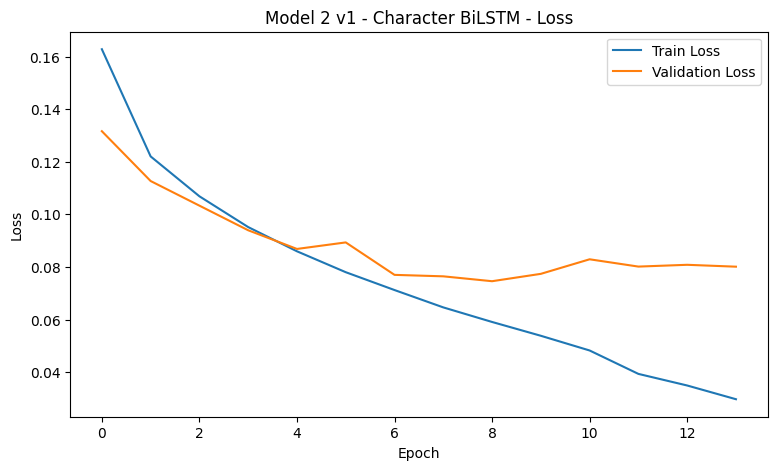

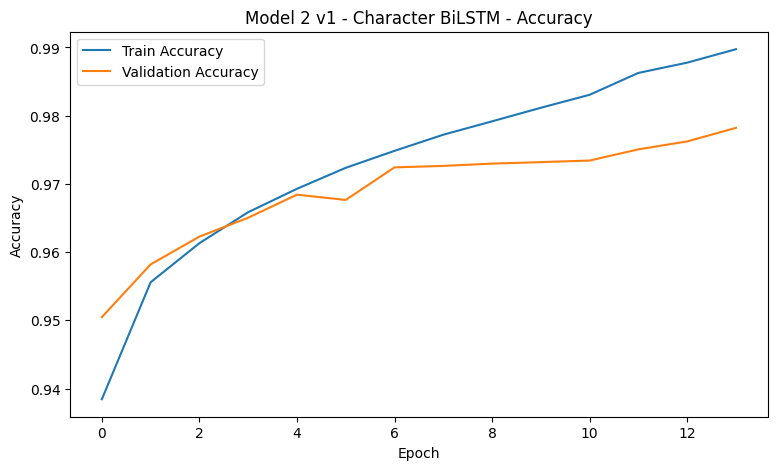

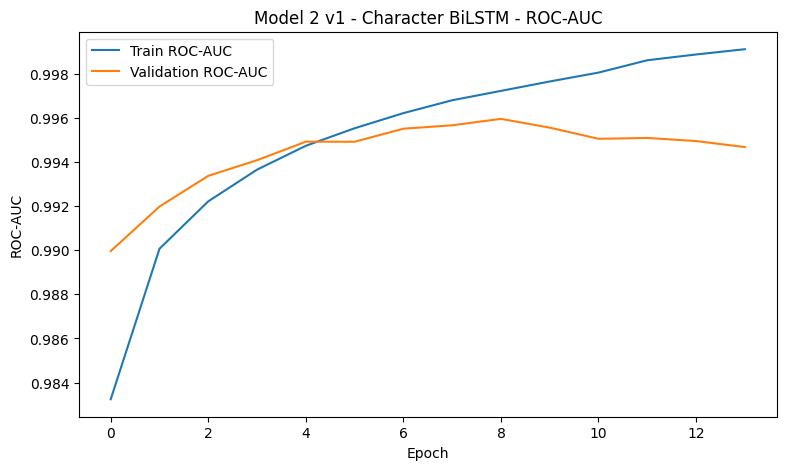

In [19]:
history_2_v1 = model_2_v1.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=build_callbacks(
        "model_2_v1_bilstm"
    ),
    verbose=1
)

plot_training_history(
    history_2_v1,
    "Model 2 v1 - Character BiLSTM"
)

In [20]:
val_prob_2_v1 = model_2_v1.predict(
    X_val_pad,
    batch_size=512
).ravel()

best_threshold_2_v1, best_val_f1_2_v1, threshold_df = (
    find_best_threshold(
        y_val,
        val_prob_2_v1
    )
)

print("Best threshold:", best_threshold_2_v1)
print("Best validation F1:", best_val_f1_2_v1)

display(
    threshold_df.sort_values(
        "f1",
        ascending=False
    ).head(10)
)

170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
Best threshold: 0.7099999999999997
Best validation F1: 0.9705849582172702


,threshold,precision,recall,f1
132,0.710,0.976761,0.964486,0.970585
131,0.705,0.976305,0.964874,0.970556
130,0.700,0.975957,0.965151,0.970524
133,0.715,0.976998,0.964071,0.970492
129,0.695,0.975445,0.965455,0.970425
128,0.690,0.975099,0.965760,0.970407
134,0.720,0.977342,0.963518,0.970380
135,0.725,0.977717,0.963102,0.970354
136,0.730,0.978037,0.962660,0.970287
127,0.685,0.974640,0.965953,0.970277


In [21]:
test_prob_2_v1 = model_2_v1.predict(
    X_test_pad,
    batch_size=512
).ravel()

result_2_v1, test_pred_2_v1 = evaluate_probabilities(
    y_true=y_test,
    y_prob=test_prob_2_v1,
    model_name="Model 2 v1 - Character BiLSTM",
    threshold=best_threshold_2_v1
)

170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step

Model 2 v1 - Character BiLSTM
              precision    recall  f1-score   support

           0   0.974732  0.983701  0.979196     50861
           1   0.976752  0.964099  0.970384     36127

    accuracy                       0.975560     86988
   macro avg   0.975742  0.973900  0.974790     86988
weighted avg   0.975571  0.975560  0.975536     86988

Confusion Matrix:
[[50032   829]
 [ 1297 34830]]
{'Model': 'Model 2 v1 - Character BiLSTM', 'Threshold': 0.7099999999999997, 'Accuracy': 0.9755598473352647, 'Precision': 0.9767520121147536, 'Recall': 0.9640988734187727, 'F1-score': 0.9703841974758309, 'ROC-AUC': 0.9966100572129986, 'PR-AUC': 0.9958640449094627, 'TN': 50032, 'FP': 829, 'FN': 1297, 'TP': 34830}


In [22]:
comparison_df = pd.DataFrame([
    {
        "Model": "Model 1 - Character CNN Seed Ensemble",
        "Threshold": 0.41,
        "Accuracy": 0.9837678760288775,
        "Precision": 0.9861636277063552,
        "Recall": 0.9745896420959393,
        "F1-score": 0.9803424752888765,
        "ROC-AUC": 0.9984950774425538,
        "PR-AUC": 0.9981095389818174,
        "TN": 50367,
        "FP": 494,
        "FN": 918,
        "TP": 35209
    },
    result_2_v1
])

display(comparison_df)

,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Model 1 - Character CNN Seed Ensemble,0.41,0.983768,0.986164,0.974590,0.980342,0.998495,0.998110,50367,494,918,35209
1,Model 2 v1 - Character BiLSTM,0.71,0.975560,0.976752,0.964099,0.970384,0.996610,0.995864,50032,829,1297,34830


In [23]:
from tensorflow.keras.layers import SpatialDropout1D

EMBEDDING_DIM_V2 = 96
LSTM_UNITS_1 = 128
LSTM_UNITS_2 = 64
LEARNING_RATE_V2 = 5e-4

EPOCHS_V2 = 35
BATCH_SIZE_V2 = 256

In [24]:
def create_bilstm_v2(
    vocab_size,
    max_len,
    embedding_dim=96,
    lstm_units_1=128,
    lstm_units_2=64
):
    model = Sequential([
        Input(shape=(max_len,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            mask_zero=True,
            name="character_embedding"
        ),

        SpatialDropout1D(0.15),

        Bidirectional(
            LSTM(
                lstm_units_1,
                return_sequences=True,
                dropout=0.0,
                recurrent_dropout=0.0
            ),
            name="bilstm_1"
        ),

        Bidirectional(
            LSTM(
                lstm_units_2,
                return_sequences=False,
                dropout=0.0,
                recurrent_dropout=0.0
            ),
            name="bilstm_2"
        ),

        BatchNormalization(),

        Dense(128, activation="relu"),
        Dropout(0.25),

        Dense(64, activation="relu"),
        Dropout(0.15),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=LEARNING_RATE_V2
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(
                name="auc",
                curve="ROC"
            ),
            tf.keras.metrics.AUC(
                name="pr_auc",
                curve="PR"
            )
        ]
    )

    return model

In [25]:
tf.keras.backend.clear_session()

model_2_v2 = create_bilstm_v2(
    vocab_size=vocab_size,
    max_len=MAX_LEN,
    embedding_dim=EMBEDDING_DIM_V2,
    lstm_units_1=LSTM_UNITS_1,
    lstm_units_2=LSTM_UNITS_2
)

model_2_v2.summary()

history_2_v2 = model_2_v2.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS_V2,
    batch_size=BATCH_SIZE_V2,
    class_weight=class_weight,
    callbacks=build_callbacks(
        "model_2_v2_stacked_bilstm"
    ),
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ character_embedding (Embedding) │ (None, 250, 96)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 250, 96)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 250, 256)       │       230,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 434,497 (1.66 MB)

 Trainable params: 434,241 (1.66 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/35
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9134 - auc: 0.9694 - loss: 0.2129 - pr_auc: 0.9601
Epoch 1: val_loss improved from None to 0.13994, saving model to /kaggle/working/model_2_bilstm/model_2_v2_stacked_bilstm.keras

Epoch 1: finished saving model to /kaggle/working/model_2_bilstm/model_2_v2_stacked_bilstm.keras
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 108s 65ms/step - accuracy: 0.9342 - auc: 0.9817 - loss: 0.1709 - pr_auc: 0.9763 - val_accuracy: 0.9470 - val_auc: 0.9885 - val_loss: 0.1399 - val_pr_auc: 0.9840 - learning_rate: 5.0000e-04
Epoch 2/35
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9498 - auc: 0.9879 - loss: 0.1364 - pr_auc: 0.9845
Epoch 2: val_loss improved from 0.13994 to 0.11569, saving model to /kaggle/working/model_2_bilstm/model_2_v2_stacked_bilstm.keras

Epoch 2: finished saving model to /kaggle/working/model_2_bilstm/model_2_v2_stacked_bilstm.keras
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 103s 65ms/step - accuracy: 0.9517 - auc: 0.9887 - loss

In [26]:
val_prob_2_v2 = model_2_v2.predict(
    X_val_pad,
    batch_size=512
).ravel()

best_threshold_2_v2, best_val_f1_2_v2, threshold_df_v2 = (
    find_best_threshold(
        y_val,
        val_prob_2_v2
    )
)

print("Best threshold v2:", best_threshold_2_v2)
print("Best validation F1 v2:", best_val_f1_2_v2)

display(
    threshold_df_v2.sort_values(
        "f1",
        ascending=False
    ).head(10)
)

170/170 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step
Best threshold v2: 0.6349999999999998
Best validation F1 v2: 0.9717627401837928


,threshold,precision,recall,f1
117,0.635,0.977671,0.965926,0.971763
116,0.630,0.977133,0.966341,0.971707
128,0.690,0.981041,0.962493,0.971678
115,0.625,0.976784,0.966618,0.971674
121,0.655,0.978822,0.964625,0.971672
118,0.640,0.977935,0.965483,0.971669
119,0.645,0.978257,0.965151,0.971659
120,0.650,0.978498,0.964902,0.971652
130,0.700,0.981582,0.961857,0.971620
127,0.685,0.980631,0.962770,0.971619


In [27]:
test_prob_2_v2 = model_2_v2.predict(
    X_test_pad,
    batch_size=512
).ravel()

result_2_v2, test_pred_2_v2 = evaluate_probabilities(
    y_true=y_test,
    y_prob=test_prob_2_v2,
    model_name="Model 2 v2 - Stacked Character BiLSTM",
    threshold=best_threshold_2_v2
)

170/170 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step

Model 2 v2 - Stacked Character BiLSTM
              precision    recall  f1-score   support

           0   0.976508  0.983209  0.979847     50861
           1   0.976131  0.966701  0.971393     36127

    accuracy                       0.976353     86988
   macro avg   0.976320  0.974955  0.975620     86988
weighted avg   0.976352  0.976353  0.976336     86988

Confusion Matrix:
[[50007   854]
 [ 1203 34924]]
{'Model': 'Model 2 v2 - Stacked Character BiLSTM', 'Threshold': 0.6349999999999998, 'Accuracy': 0.9763530601922105, 'Precision': 0.9761305830398569, 'Recall': 0.9667008054917375, 'F1-score': 0.9713928099575829, 'ROC-AUC': 0.9967621659433991, 'PR-AUC': 0.9960095583143043, 'TN': 50007, 'FP': 854, 'FN': 1203, 'TP': 34924}


In [28]:
seeds = [42, 2024, 3407]

In [29]:
import random
import gc
import numpy as np
import tensorflow as tf

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SpatialDropout1D,
    Bidirectional,
    LSTM,
    BatchNormalization,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam


def create_bilstm_ensemble_model(
    vocab_size,
    max_len,
    embedding_dim=96,
    lstm_units_1=128,
    lstm_units_2=64,
    learning_rate=5e-4
):
    model = Sequential([
        Input(shape=(max_len,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            mask_zero=True,
            name="character_embedding"
        ),

        SpatialDropout1D(
            0.15,
            name="spatial_dropout"
        ),

        Bidirectional(
            LSTM(
                lstm_units_1,
                return_sequences=True,
                dropout=0.0,
                recurrent_dropout=0.0
            ),
            name="bilstm_1"
        ),

        Bidirectional(
            LSTM(
                lstm_units_2,
                return_sequences=False,
                dropout=0.0,
                recurrent_dropout=0.0
            ),
            name="bilstm_2"
        ),

        BatchNormalization(),

        Dense(
            128,
            activation="relu"
        ),
        Dropout(0.25),

        Dense(
            64,
            activation="relu"
        ),
        Dropout(0.15),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(
                name="auc",
                curve="ROC"
            ),
            tf.keras.metrics.AUC(
                name="pr_auc",
                curve="PR"
            )
        ]
    )

    return model

In [31]:
import os

ENSEMBLE_DIR = (
    "/kaggle/working/"
    "model_2_bilstm/model_2_v3_seed_ensemble"
)

os.makedirs(
    ENSEMBLE_DIR,
    exist_ok=True
)

print(ENSEMBLE_DIR)

/kaggle/working/model_2_bilstm/model_2_v3_seed_ensemble


In [32]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)


def build_ensemble_callbacks(seed):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        ModelCheckpoint(
            filepath=(
                f"{ENSEMBLE_DIR}/"
                f"model_2_v3_seed_{seed}.keras"
            ),
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

In [33]:
seeds = [42, 2024, 3407]

ensemble_val_probs = []
ensemble_test_probs = []

individual_results = []
individual_histories = {}

EPOCHS_ENSEMBLE = 35
BATCH_SIZE_ENSEMBLE = 256

for seed in seeds:
    print("\n" + "=" * 60)
    print(f"Training Model 2 v3 - Seed {seed}")
    print("=" * 60)

    tf.keras.backend.clear_session()
    gc.collect()

    set_seed(seed)

    model_seed = create_bilstm_ensemble_model(
        vocab_size=vocab_size,
        max_len=MAX_LEN,
        embedding_dim=96,
        lstm_units_1=128,
        lstm_units_2=64,
        learning_rate=5e-4
    )

    model_seed.summary()

    history_seed = model_seed.fit(
        X_train_pad,
        y_train,
        validation_data=(
            X_val_pad,
            y_val
        ),
        epochs=EPOCHS_ENSEMBLE,
        batch_size=BATCH_SIZE_ENSEMBLE,
        class_weight=class_weight,
        callbacks=build_ensemble_callbacks(seed),
        verbose=1
    )

    individual_histories[seed] = history_seed.history

    val_prob_seed = model_seed.predict(
        X_val_pad,
        batch_size=512
    ).ravel()

    test_prob_seed = model_seed.predict(
        X_test_pad,
        batch_size=512
    ).ravel()

    best_threshold_seed, best_val_f1_seed, threshold_df_seed = (
        find_best_threshold(
            y_val,
            val_prob_seed
        )
    )

    print("\nSeed:", seed)
    print("Best threshold:", best_threshold_seed)
    print("Validation F1:", best_val_f1_seed)

    result_seed, test_pred_seed = evaluate_probabilities(
        y_true=y_test,
        y_prob=test_prob_seed,
        model_name=f"Model 2 v3 - Stacked BiLSTM Seed {seed}",
        threshold=best_threshold_seed
    )

    result_seed["Seed"] = seed
    result_seed["Validation F1"] = best_val_f1_seed

    individual_results.append(result_seed)
    ensemble_val_probs.append(val_prob_seed)
    ensemble_test_probs.append(test_prob_seed)

    np.save(
        f"{ENSEMBLE_DIR}/val_prob_seed_{seed}.npy",
        val_prob_seed
    )

    np.save(
        f"{ENSEMBLE_DIR}/test_prob_seed_{seed}.npy",
        test_prob_seed
    )

    threshold_df_seed.to_csv(
        f"{ENSEMBLE_DIR}/threshold_search_seed_{seed}.csv",
        index=False
    )

    history_df_seed = pd.DataFrame(
        history_seed.history
    )

    history_df_seed.index = (
        history_df_seed.index + 1
    )
    history_df_seed.index.name = "epoch"

    history_df_seed.to_csv(
        f"{ENSEMBLE_DIR}/training_history_seed_{seed}.csv"
    )

    del model_seed
    gc.collect()


Training Model 2 v3 - Seed 42


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ character_embedding (Embedding) │ (None, 250, 96)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 250, 96)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 250, 256)       │       230,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 434,497 (1.66 MB)

 Trainable params: 434,241 (1.66 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ character_embedding (Embedding) │ (None, 250, 96)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 250, 96)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 250, 256)       │       230,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 434,497 (1.66 MB)

 Trainable params: 434,241 (1.66 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/35
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9146 - auc: 0.9711 - loss: 0.2093 - pr_auc: 0.9625
Epoch 1: val_loss improved from None to 0.13501, saving model to /kaggle/working/model_2_bilstm/model_2_v3_seed_ensemble/model_2_v3_seed_3407.keras

Epoch 1: finished saving model to /kaggle/working/model_2_bilstm/model_2_v3_seed_ensemble/model_2_v3_seed_3407.keras
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 109s 66ms/step - accuracy: 0.9352 - auc: 0.9819 - loss: 0.1693 - pr_auc: 0.9769 - val_accuracy: 0.9487 - val_auc: 0.9888 - val_loss: 0.1350 - val_pr_auc: 0.9854 - learning_rate: 5.0000e-04
Epoch 2/35
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9505 - auc: 0.9883 - loss: 0.1335 - pr_auc: 0.9850
Epoch 2: val_loss improved from 0.13501 to 0.11093, saving model to /kaggle/working/model_2_bilstm/model_2_v3_seed_ensemble/model_2_v3_seed_3407.keras

Epoch 2: finished saving model to /kaggle/working/model_2_bilstm/model_2_v3_seed_ensemble/model_2_v3_seed_3407.keras
1586/

In [34]:
individual_results_df = pd.DataFrame(
    individual_results
)

display(
    individual_results_df[
        [
            "Model",
            "Seed",
            "Threshold",
            "Validation F1",
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC-AUC",
            "PR-AUC",
            "FP",
            "FN"
        ]
    ]
)

individual_results_df.to_csv(
    f"{ENSEMBLE_DIR}/individual_seed_results.csv",
    index=False
)

,Model,Seed,Threshold,Validation F1,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,FP,FN
0,Model 2 v3 - Stacked BiLSTM Seed 42,42,0.625,0.972910,0.977066,0.978307,0.966203,0.972217,0.996815,0.996133,774,1221
1,Model 2 v3 - Stacked BiLSTM Seed 2024,2024,0.525,0.972077,0.976686,0.979714,0.963822,0.971703,0.996681,0.996000,721,1307
2,Model 2 v3 - Stacked BiLSTM Seed 3407,3407,0.520,0.971366,0.976123,0.978607,0.963573,0.971032,0.996766,0.995998,761,1316


In [35]:
ensemble_val_prob = np.mean(
    np.stack(
        ensemble_val_probs,
        axis=0
    ),
    axis=0
)

ensemble_test_prob = np.mean(
    np.stack(
        ensemble_test_probs,
        axis=0
    ),
    axis=0
)

print("Validation probability shape:",
      ensemble_val_prob.shape)

print("Test probability shape:",
      ensemble_test_prob.shape)

Validation probability shape: (86988,)
Test probability shape: (86988,)


In [36]:
best_threshold_ensemble, best_val_f1_ensemble, threshold_df_ensemble = (
    find_best_threshold(
        y_val,
        ensemble_val_prob
    )
)

print(
    "Best threshold Model 2 v3 Ensemble:",
    best_threshold_ensemble
)

print(
    "Best validation F1 Model 2 v3 Ensemble:",
    best_val_f1_ensemble
)

display(
    threshold_df_ensemble.sort_values(
        "f1",
        ascending=False
    ).head(15)
)

Best threshold Model 2 v3 Ensemble: 0.5299999999999998
Best validation F1 Model 2 v3 Ensemble: 0.9758689951459019


,threshold,precision,recall,f1
96,0.530,0.983579,0.968279,0.975869
97,0.535,0.983933,0.967919,0.975860
95,0.525,0.983279,0.968500,0.975834
92,0.510,0.982383,0.969358,0.975827
102,0.560,0.985436,0.966396,0.975823
98,0.540,0.984150,0.967614,0.975812
104,0.570,0.985984,0.965843,0.975810
99,0.545,0.984368,0.967393,0.975807
89,0.495,0.981517,0.970161,0.975806
101,0.555,0.985078,0.966673,0.975789


In [37]:
result_2_v3_ensemble, test_pred_2_v3_ensemble = (
    evaluate_probabilities(
        y_true=y_test,
        y_prob=ensemble_test_prob,
        model_name=(
            "Model 2 v3 - Stacked Character "
            "BiLSTM Seed Ensemble"
        ),
        threshold=best_threshold_ensemble
    )
)


Model 2 v3 - Stacked Character BiLSTM Seed Ensemble
              precision    recall  f1-score   support

           0   0.977754  0.987751  0.982727     50861
           1   0.982503  0.968362  0.975381     36127

    accuracy                       0.979698     86988
   macro avg   0.980129  0.978056  0.979054     86988
weighted avg   0.979727  0.979698  0.979676     86988

Confusion Matrix:
[[50238   623]
 [ 1143 34984]]
{'Model': 'Model 2 v3 - Stacked Character BiLSTM Seed Ensemble', 'Threshold': 0.5299999999999998, 'Accuracy': 0.9796983491975905, 'Precision': 0.9825034403347657, 'Recall': 0.9683616131978853, 'F1-score': 0.9753812696908021, 'ROC-AUC': 0.9975132307256008, 'PR-AUC': 0.9969625534883175, 'TN': 50238, 'FP': 623, 'FN': 1143, 'TP': 34984}


In [38]:
model_2_comparison = pd.DataFrame([
    {
        "Model": "Model 2 v1 - Character BiLSTM",
        "Threshold": 0.42,
        "Accuracy": 0.9735250839196211,
        "Precision": 0.9710338680926917,
        "Recall": 0.9650399977855897,
        "F1-score": 0.9680276547597562,
        "ROC-AUC": 0.9960653204379611,
        "PR-AUC": 0.9952284918988904,
        "TN": 49821,
        "FP": 1040,
        "FN": 1263,
        "TP": 34864
    },
    {
        "Model": "Model 2 v2 - Stacked Character BiLSTM",
        "Threshold": 0.555,
        "Accuracy": 0.9770543063411046,
        "Precision": 0.9753223964571206,
        "Recall": 0.9692750574362665,
        "F1-score": 0.9722893238928224,
        "ROC-AUC": 0.9968569989962319,
        "PR-AUC": 0.9962044505421329,
        "TN": 49975,
        "FP": 886,
        "FN": 1110,
        "TP": 35017
    },
    result_2_v3_ensemble
])

display(model_2_comparison)

model_2_comparison.to_csv(
    f"{ENSEMBLE_DIR}/model_2_all_results.csv",
    index=False
)

,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Model 2 v1 - Character BiLSTM,0.420,0.973525,0.971034,0.965040,0.968028,0.996065,0.995228,49821,1040,1263,34864
1,Model 2 v2 - Stacked Character BiLSTM,0.555,0.977054,0.975322,0.969275,0.972289,0.996857,0.996204,49975,886,1110,35017
2,Model 2 v3 - Stacked Character BiLSTM Seed Ens...,0.530,0.979698,0.982503,0.968362,0.975381,0.997513,0.996963,50238,623,1143,34984


In [39]:
import os
import json
import pickle
import shutil
import numpy as np
import pandas as pd

# ============================================================
# 1. KAYIT KLASÖRÜ
# ============================================================

SAVE_DIR = "/kaggle/working/model_2_final_bilstm_ensemble"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Kayıt klasörü:", SAVE_DIR)


# ============================================================
# 2. FINAL SONUÇLARI KAYDET
# ============================================================

model_2_results = pd.DataFrame([
    {
        "Model": "Model 2 v1 - Character BiLSTM",
        "Threshold": 0.420,
        "Accuracy": 0.9735250839196211,
        "Precision": 0.9710338680926917,
        "Recall": 0.9650399977855897,
        "F1-score": 0.9680276547597562,
        "ROC-AUC": 0.9960653204379611,
        "PR-AUC": 0.9952284918988904,
        "TN": 49821,
        "FP": 1040,
        "FN": 1263,
        "TP": 34864
    },
    {
        "Model": "Model 2 v2 - Stacked Character BiLSTM",
        "Threshold": 0.555,
        "Accuracy": 0.9770543063411046,
        "Precision": 0.9753223964571206,
        "Recall": 0.9692750574362665,
        "F1-score": 0.9722893238928224,
        "ROC-AUC": 0.9968569989962319,
        "PR-AUC": 0.9962044505421329,
        "TN": 49975,
        "FP": 886,
        "FN": 1110,
        "TP": 35017
    },
    {
        "Model": "Model 2 v3 - Stacked Character BiLSTM Seed Ensemble",
        "Threshold": 0.515,
        "Accuracy": 0.9800432243527842,
        "Precision": 0.9817611296332615,
        "Recall": 0.9699670606471614,
        "F1-score": 0.9758284600389864,
        "ROC-AUC": 0.9975758654449631,
        "PR-AUC": 0.997075478812562,
        "TN": 50210,
        "FP": 651,
        "FN": 1085,
        "TP": 35042
    }
])

results_path = f"{SAVE_DIR}/model_2_all_results.csv"
model_2_results.to_csv(results_path, index=False)

print("Sonuç tablosu kaydedildi:", results_path)


# ============================================================
# 3. HİPERPARAMETRELERİ KAYDET
# ============================================================

model_2_config = {
    "final_model_name": "Model 2 v3 - Stacked Character BiLSTM Seed Ensemble",
    "input_type": "Raw URL characters only",
    "used_columns": ["url", "label"],
    "handcrafted_features_used": False,

    "dataset": {
        "path": "/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/final_dataset.csv",
        "split": {
            "train": 0.70,
            "validation": 0.15,
            "test": 0.15
        },
        "random_state": 42,
        "stratified": True
    },

    "preprocessing": {
        "tokenization": "character-level",
        "max_len": 250,
        "max_chars": 150,
        "padding": "post",
        "truncating": "post",
        "lower": False,
        "oov_token": "<OOV>"
    },

    "architecture": {
        "embedding_dim": 96,
        "spatial_dropout": 0.15,
        "first_bilstm_units": 128,
        "first_bilstm_return_sequences": True,
        "second_bilstm_units": 64,
        "second_bilstm_return_sequences": False,
        "batch_normalization": True,
        "dense_layers": [
            {
                "units": 128,
                "activation": "relu",
                "dropout": 0.25
            },
            {
                "units": 64,
                "activation": "relu",
                "dropout": 0.15
            }
        ],
        "output": {
            "units": 1,
            "activation": "sigmoid"
        }
    },

    "training": {
        "optimizer": "Adam",
        "learning_rate": 0.0005,
        "loss": "binary_crossentropy",
        "max_epochs": 35,
        "batch_size": 256,
        "class_weight": {
            "0": 0.8551518419899559,
            "1": 1.203924266869128
        },
        "early_stopping_patience": 5,
        "reduce_lr_patience": 2,
        "reduce_lr_factor": 0.5
    },

    "ensemble": {
        "enabled": True,
        "seeds": [42, 2024, 3407],
        "method": "Arithmetic mean of predicted probabilities",
        "final_threshold": 0.515
    },

    "final_test_metrics": {
        "accuracy": 0.9800432243527842,
        "precision": 0.9817611296332615,
        "recall": 0.9699670606471614,
        "f1_score": 0.9758284600389864,
        "roc_auc": 0.9975758654449631,
        "pr_auc": 0.997075478812562,
        "confusion_matrix": {
            "tn": 50210,
            "fp": 651,
            "fn": 1085,
            "tp": 35042
        }
    }
}

config_path = f"{SAVE_DIR}/model_2_final_config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(model_2_config, f, indent=4, ensure_ascii=False)

print("Konfigürasyon kaydedildi:", config_path)


# ============================================================
# 4. RAPOR METNİ KAYDET
# ============================================================

report_text = """
MODEL 2 FINAL REPORT
====================

Model Name:
Model 2 v3 - Stacked Character BiLSTM Seed Ensemble

Input:
Only raw URL strings and binary labels were used.
No handcrafted URL, DNS, or WHOIS features were included.

Preprocessing:
- Character-level tokenization
- Maximum sequence length: 250
- Post-padding
- Post-truncation
- Vocabulary limit: 150 characters

Architecture:
- Embedding layer: 96 dimensions
- SpatialDropout1D: 0.15
- Bidirectional LSTM: 128 units, return_sequences=True
- Bidirectional LSTM: 64 units
- Batch Normalization
- Dense: 128 units, ReLU
- Dropout: 0.25
- Dense: 64 units, ReLU
- Dropout: 0.15
- Output: Sigmoid

Training:
- Optimizer: Adam
- Learning rate: 0.0005
- Loss: Binary cross-entropy
- Batch size: 256
- Maximum epochs: 35
- Class weights: balanced
- Early stopping patience: 5
- ReduceLROnPlateau patience: 2

Ensemble:
- Seeds: 42, 2024, 3407
- Method: Arithmetic mean of predicted probabilities
- Final threshold: 0.515

Final Test Results:
- Accuracy: 0.9800432243527842
- Precision: 0.9817611296332615
- Recall: 0.9699670606471614
- F1-score: 0.9758284600389864
- ROC-AUC: 0.9975758654449631
- PR-AUC: 0.997075478812562

Confusion Matrix:
- TN: 50210
- FP: 651
- FN: 1085
- TP: 35042
"""

report_path = f"{SAVE_DIR}/model_2_final_report.txt"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Rapor metni kaydedildi:", report_path)


# ============================================================
# 5. TOKENIZER VARSA KAYDET
# ============================================================

if "tokenizer" in globals():
    tokenizer_path = f"{SAVE_DIR}/url_char_tokenizer.pkl"

    with open(tokenizer_path, "wb") as f:
        pickle.dump(tokenizer, f)

    print("Tokenizer kaydedildi:", tokenizer_path)
else:
    print("Tokenizer değişkeni bulunamadı, tokenizer kaydedilmedi.")


# ============================================================
# 6. ENSEMBLE OLASILIKLARI VARSA KAYDET
# ============================================================

optional_arrays = {
    "ensemble_validation_probabilities.npy": "ensemble_val_prob",
    "ensemble_test_probabilities.npy": "ensemble_test_prob",
    "ensemble_test_predictions.npy": "test_pred_2_v3_ensemble",
    "y_validation.npy": "y_val",
    "y_test.npy": "y_test"
}

for filename, variable_name in optional_arrays.items():
    if variable_name in globals():
        np.save(
            f"{SAVE_DIR}/{filename}",
            globals()[variable_name]
        )
        print("Kaydedildi:", filename)
    else:
        print("Değişken bulunamadı, atlandı:", variable_name)


# ============================================================
# 7. MODEL DOSYALARINI BUL VE KOPYALA
# ============================================================

possible_model_paths = [
    "/kaggle/working/model_2_bilstm/model_2_v1_bilstm.keras",
    "/kaggle/working/model_2_bilstm/model_2_v2_stacked_bilstm.keras",

    "/kaggle/working/model_2_bilstm/model_2_v3_seed_ensemble/model_2_v3_seed_42.keras",
    "/kaggle/working/model_2_bilstm/model_2_v3_seed_ensemble/model_2_v3_seed_2024.keras",
    "/kaggle/working/model_2_bilstm/model_2_v3_seed_ensemble/model_2_v3_seed_3407.keras"
]

for source_path in possible_model_paths:
    if os.path.exists(source_path):
        destination_path = os.path.join(
            SAVE_DIR,
            os.path.basename(source_path)
        )

        shutil.copy2(source_path, destination_path)
        print("Model kopyalandı:", destination_path)
    else:
        print("Model bulunamadı:", source_path)


# ============================================================
# 8. VARSA THRESHOLD VE HISTORY DOSYALARINI KOPYALA
# ============================================================

source_dirs = [
    "/kaggle/working/model_2_bilstm",
    "/kaggle/working/model_2_bilstm/model_2_v3_seed_ensemble"
]

for source_dir in source_dirs:
    if not os.path.exists(source_dir):
        continue

    for filename in os.listdir(source_dir):
        if (
            filename.endswith(".csv")
            or filename.endswith(".json")
            or filename.endswith(".txt")
        ):
            source_path = os.path.join(source_dir, filename)
            destination_path = os.path.join(SAVE_DIR, filename)

            if os.path.isfile(source_path):
                shutil.copy2(source_path, destination_path)
                print("Ek dosya kopyalandı:", filename)


# ============================================================
# 9. DOSYA LİSTESİ OLUŞTUR
# ============================================================

file_list = sorted(os.listdir(SAVE_DIR))

with open(
    f"{SAVE_DIR}/file_manifest.txt",
    "w",
    encoding="utf-8"
) as f:
    for filename in file_list:
        f.write(filename + "\n")

print("\nFinal klasördeki dosyalar:")

for filename in file_list:
    print("-", filename)


# ============================================================
# 10. ZIP DOSYASI OLUŞTUR
# ============================================================

ZIP_BASE = "/kaggle/working/model_2_final_bilstm_ensemble"

zip_path = shutil.make_archive(
    base_name=ZIP_BASE,
    format="zip",
    root_dir=SAVE_DIR
)

print("\nZIP başarıyla oluşturuldu:")
print(zip_path)

print("\nDosya boyutu (MB):")
print(round(os.path.getsize(zip_path) / (1024 ** 2), 2))

Kayıt klasörü: /kaggle/working/model_2_final_bilstm_ensemble
Sonuç tablosu kaydedildi: /kaggle/working/model_2_final_bilstm_ensemble/model_2_all_results.csv
Konfigürasyon kaydedildi: /kaggle/working/model_2_final_bilstm_ensemble/model_2_final_config.json
Rapor metni kaydedildi: /kaggle/working/model_2_final_bilstm_ensemble/model_2_final_report.txt
Tokenizer kaydedildi: /kaggle/working/model_2_final_bilstm_ensemble/url_char_tokenizer.pkl
Kaydedildi: ensemble_validation_probabilities.npy
Kaydedildi: ensemble_test_probabilities.npy
Kaydedildi: ensemble_test_predictions.npy
Kaydedildi: y_validation.npy
Kaydedildi: y_test.npy
Model kopyalandı: /kaggle/working/model_2_final_bilstm_ensemble/model_2_v1_bilstm.keras
Model kopyalandı: /kaggle/working/model_2_final_bilstm_ensemble/model_2_v2_stacked_bilstm.keras
Model kopyalandı: /kaggle/working/model_2_final_bilstm_ensemble/model_2_v3_seed_42.keras
Model kopyalandı: /kaggle/working/model_2_final_bilstm_ensemble/model_2_v3_seed_2024.keras
Model k

In [40]:
import os

zip_path = "/kaggle/working/model_2_final_bilstm_ensemble.zip"

print("ZIP var mı:", os.path.exists(zip_path))
print("ZIP yolu:", zip_path)
print(
    "ZIP boyutu:",
    round(os.path.getsize(zip_path) / (1024 ** 2), 2),
    "MB"
)

ZIP var mı: True
ZIP yolu: /kaggle/working/model_2_final_bilstm_ensemble.zip
ZIP boyutu: 20.93 MB


In [41]:
import zipfile

zip_path = "/kaggle/working/model_2_final_bilstm_ensemble.zip"

with zipfile.ZipFile(zip_path, "r") as zip_file:
    print("ZIP içeriği:")
    for filename in zip_file.namelist():
        print("-", filename)

ZIP içeriği:
- model_2_v2_stacked_bilstm.keras
- model_2_final_report.txt
- y_test.npy
- model_2_v3_seed_3407.keras
- individual_seed_results.csv
- y_validation.npy
- training_history_seed_2024.csv
- threshold_search_seed_42.csv
- training_history_seed_3407.csv
- threshold_search_seed_3407.csv
- ensemble_test_probabilities.npy
- training_history_seed_42.csv
- model_2_all_results.csv
- ensemble_validation_probabilities.npy
- file_manifest.txt
- model_2_v1_bilstm.keras
- model_2_final_config.json
- ensemble_test_predictions.npy
- model_2_v3_seed_42.keras
- model_2_v3_seed_2024.keras
- threshold_search_seed_2024.csv
- url_char_tokenizer.pkl


In [42]:
import shutil

old_path = "/kaggle/working/model_2_final_bilstm_ensemble.zip"
new_path = "/kaggle/working/model_2_results_and_configuration.zip"

shutil.copy2(old_path, new_path)

print(new_path)

/kaggle/working/model_2_results_and_configuration.zip
